# Exercise 7 – Time Series Prediction with LSTM and GRU

## Objective
Implement GRU and Recurrent Neural Networks (RNNs) in Python for time series prediction using PyTorch.

## Table of Contents
1. Introduction and Dataset Selection
2. Data Loading and Exploration
3. Data Preprocessing
4. Building LSTM Model
5. Building GRU Model
6. Training and Validation
7. Model Evaluation and Metrics
8. Results Visualization
9. Conclusions and Insights


## 1. Introduction and Dataset Selection

For this exercise, we will use **Stock Market Data** (S&P 500) for time series prediction. We'll predict future stock prices based on historical data.

**Dataset**: We'll use Yahoo Finance data via the `yfinance` library to get historical stock prices.

**Models**: We'll implement and compare:
- **LSTM (Long Short-Term Memory)**: A type of RNN that can learn long-term dependencies
- **GRU (Gated Recurrent Unit)**: A simpler variant of LSTM with fewer parameters

**Task**: Predict the next day's closing price based on previous days' data.


In [26]:
# Install required libraries (run this if needed)
# !pip install yfinance pandas numpy matplotlib torch scikit-learn


## 2. Data Loading and Exploration


In [27]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [28]:
# Download S&P 500 stock data
# Using Apple Inc. (AAPL) as an example - you can change this to any stock symbol
ticker = " NVDA"
start_date = "2015-01-01"
end_date = "2024-01-01"

# Download the data
stock_data = yf.download(ticker, start=start_date, end=end_date)

print(f"Dataset shape: {stock_data.shape}")
print(f"\nFirst few rows:")
print(stock_data.head())
print(f"\nDataset info:")
print(stock_data.info())
print(f"\nBasic statistics:")
print(stock_data.describe())


[*********************100%***********************]  1 of 1 completed

Dataset shape: (2264, 5)

First few rows:
Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2015-01-02  0.483011  0.486611  0.475333  0.483011  113680000
2015-01-05  0.474853  0.484451  0.472694  0.483011  197952000
2015-01-06  0.460457  0.476053  0.459977  0.475573  197764000
2015-01-07  0.459257  0.467895  0.457817  0.463816  321808000
2015-01-08  0.476533  0.479412  0.464296  0.464535  283780000

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2015-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   2264 non-null   float64
 1   (High, NVDA)    2264 non-null   float64
 2   (Low, NVDA)     2264 non-null   float64
 3   (Open, NVDA)    2264 non-null   float64
 4   (Volume, NVDA)  2264 non-null   int64  
dtypes: 

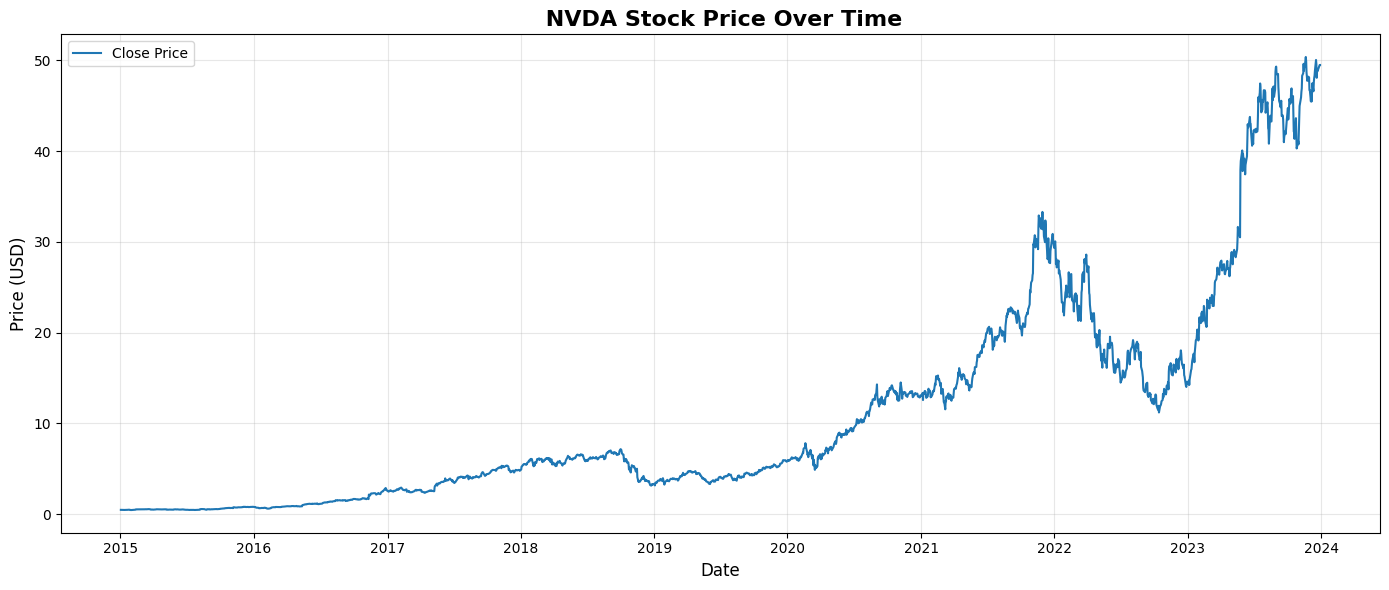

In [29]:
# Visualize the stock price over time
plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', linewidth=1.5)
plt.title(f'{ticker} Stock Price Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

For time series prediction, we need to:
1. Select the feature(s) to predict (we'll use 'Close' price)
2. Scale the data to [0, 1] range for better training
3. Create sequences: use past N days to predict the next day
4. Split into train/validation/test sets


In [30]:
# Extract the closing prices
data = stock_data['Close'].values.reshape(-1, 1)

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Original data shape: {data.shape}")
print(f"Scaled data shape: {scaled_data.shape}")
print(f"Scaled data range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")


Original data shape: (2264, 1)
Scaled data shape: (2264, 1)
Scaled data range: [0.0000, 1.0000]


In [31]:
# Function to create sequences for time series prediction
def create_sequences(data, seq_length):
    """
    Create sequences of data for time series prediction.

    Args:
        data: Array of scaled values
        seq_length: Number of time steps to look back

    Returns:
        X: Input sequences (samples, seq_length, features)
        y: Target values (samples,)
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Set sequence length (number of days to look back)
sequence_length = 60  # Using 60 days to predict the next day

# Create sequences
X, y = create_sequences(scaled_data, sequence_length)

print(f"X shape: {X.shape}")  # (samples, sequence_length, features)
print(f"y shape: {y.shape}")   # (samples,)


X shape: (2204, 60, 1)
y shape: (2204, 1)


In [32]:
# Split the data into train, validation, and test sets
# 70% train, 15% validation, 15% test
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 1542 samples
Validation set: 330 samples
Test set: 332 samples


In [33]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print(f"Training tensors shape: {X_train_tensor.shape}, {y_train_tensor.shape}")


Training tensors shape: torch.Size([1542, 60, 1]), torch.Size([1542, 1])


## 4. Building LSTM Model


In [34]:
class LSTMModel(nn.Module):
    """
    LSTM model for time series prediction.

    Architecture:
    - LSTM layer(s) to capture temporal dependencies
    - Dropout for regularization
    - Fully connected layer for prediction
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))

        # Take the last output
        out = out[:, -1, :]

        # Apply dropout
        out = self.dropout(out)

        # Fully connected layer
        out = self.fc(out)

        return out

# Initialize the LSTM model
lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print("LSTM Model Architecture:")
print(lstm_model)


LSTM Model Architecture:
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Building GRU Model


In [35]:
class GRUModel(nn.Module):
    """
    GRU model for time series prediction.

    Architecture:
    - GRU layer(s) to capture temporal dependencies
    - Dropout for regularization
    - Fully connected layer for prediction
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layer
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # GRU forward pass
        out, _ = self.gru(x, h0)

        # Take the last output
        out = out[:, -1, :]

        # Apply dropout
        out = self.dropout(out)

        # Fully connected layer
        out = self.fc(out)

        return out

# Initialize the GRU model
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print("GRU Model Architecture:")
print(gru_model)


GRU Model Architecture:
GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Training and Validation

We'll train both models and track their training/validation losses.


In [36]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=100, lr=0.001, batch_size=32):
    """
    Train the model and return training history.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                           factor=0.5, patience=10)

    train_losses = []
    val_losses = []

    # Create data loaders
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0
    patience = 20

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_predictions = model(X_val)
            val_loss = criterion(val_predictions, y_val).item()
            val_losses.append(val_loss)

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))

    return train_losses, val_losses

# Training parameters
epochs = 100
learning_rate = 0.001
batch_size = 32


In [37]:
# Train LSTM model
print("=" * 50)
print("Training LSTM Model")
print("=" * 50)
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=epochs, lr=learning_rate, batch_size=batch_size
)


Training LSTM Model
Epoch [10/100], Train Loss: 0.000330, Val Loss: 0.001494
Epoch [20/100], Train Loss: 0.000234, Val Loss: 0.001232
Epoch [30/100], Train Loss: 0.000180, Val Loss: 0.001034
Epoch [40/100], Train Loss: 0.000166, Val Loss: 0.001591
Epoch [50/100], Train Loss: 0.000126, Val Loss: 0.000877
Epoch [60/100], Train Loss: 0.000103, Val Loss: 0.001127
Epoch [70/100], Train Loss: 0.000085, Val Loss: 0.000754
Epoch [80/100], Train Loss: 0.000075, Val Loss: 0.000984
Early stopping at epoch 82


In [38]:
# Train GRU model
print("\n" + "=" * 50)
print("Training GRU Model")
print("=" * 50)
gru_train_losses, gru_val_losses = train_model(
    gru_model, X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=epochs, lr=learning_rate, batch_size=batch_size
)



Training GRU Model
Epoch [10/100], Train Loss: 0.000109, Val Loss: 0.000871
Epoch [20/100], Train Loss: 0.000089, Val Loss: 0.000768
Epoch [30/100], Train Loss: 0.000082, Val Loss: 0.000581
Epoch [40/100], Train Loss: 0.000076, Val Loss: 0.000614
Epoch [50/100], Train Loss: 0.000068, Val Loss: 0.000738
Epoch [60/100], Train Loss: 0.000065, Val Loss: 0.000450
Epoch [70/100], Train Loss: 0.000062, Val Loss: 0.000621
Epoch [80/100], Train Loss: 0.000070, Val Loss: 0.000923
Epoch [90/100], Train Loss: 0.000064, Val Loss: 0.000579
Epoch [100/100], Train Loss: 0.000061, Val Loss: 0.000711


## 7. Model Evaluation and Metrics

We'll evaluate both models on the test set using RMSE and MAE metrics.


In [39]:
def evaluate_model(model, X_test, y_test, scaler):
    """
    Evaluate the model and return predictions and metrics.
    """
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)

    # Convert to numpy
    predictions_np = predictions.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Inverse transform to get actual prices
    predictions_actual = scaler.inverse_transform(predictions_np)
    y_test_actual = scaler.inverse_transform(y_test_np)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
    mae = mean_absolute_error(y_test_actual, predictions_actual)

    # Calculate MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100

    return predictions_actual, y_test_actual, rmse, mae, mape

# Evaluate LSTM model
print("=" * 50)
print("LSTM Model Evaluation")
print("=" * 50)
lstm_pred, lstm_actual, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(
    lstm_model, X_test_tensor, y_test_tensor, scaler
)
print(f"RMSE: ${lstm_rmse:.2f}")
print(f"MAE: ${lstm_mae:.2f}")
print(f"MAPE: {lstm_mape:.2f}%")


LSTM Model Evaluation
RMSE: $3.95
MAE: $2.97
MAPE: 8.10%


In [40]:
# Evaluate GRU model
print("\n" + "=" * 50)
print("GRU Model Evaluation")
print("=" * 50)
gru_pred, gru_actual, gru_rmse, gru_mae, gru_mape = evaluate_model(
    gru_model, X_test_tensor, y_test_tensor, scaler
)
print(f"RMSE: ${gru_rmse:.2f}")
print(f"MAE: ${gru_mae:.2f}")
print(f"MAPE: {gru_mape:.2f}%")



GRU Model Evaluation
RMSE: $1.93
MAE: $1.44
MAPE: 4.24%


## 8. Results Visualization


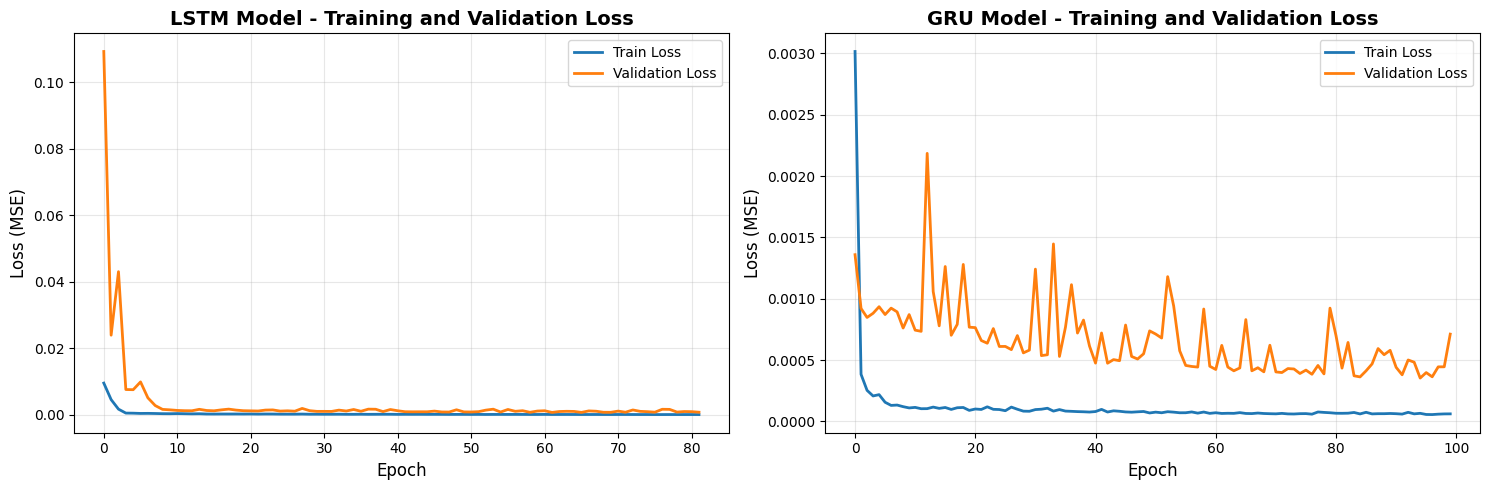

In [41]:
# Plot training and validation loss for both models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LSTM losses
axes[0].plot(lstm_train_losses, label='Train Loss', linewidth=2)
axes[0].plot(lstm_val_losses, label='Validation Loss', linewidth=2)
axes[0].set_title('LSTM Model - Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU losses
axes[1].plot(gru_train_losses, label='Train Loss', linewidth=2)
axes[1].plot(gru_val_losses, label='Validation Loss', linewidth=2)
axes[1].set_title('GRU Model - Training and Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (MSE)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


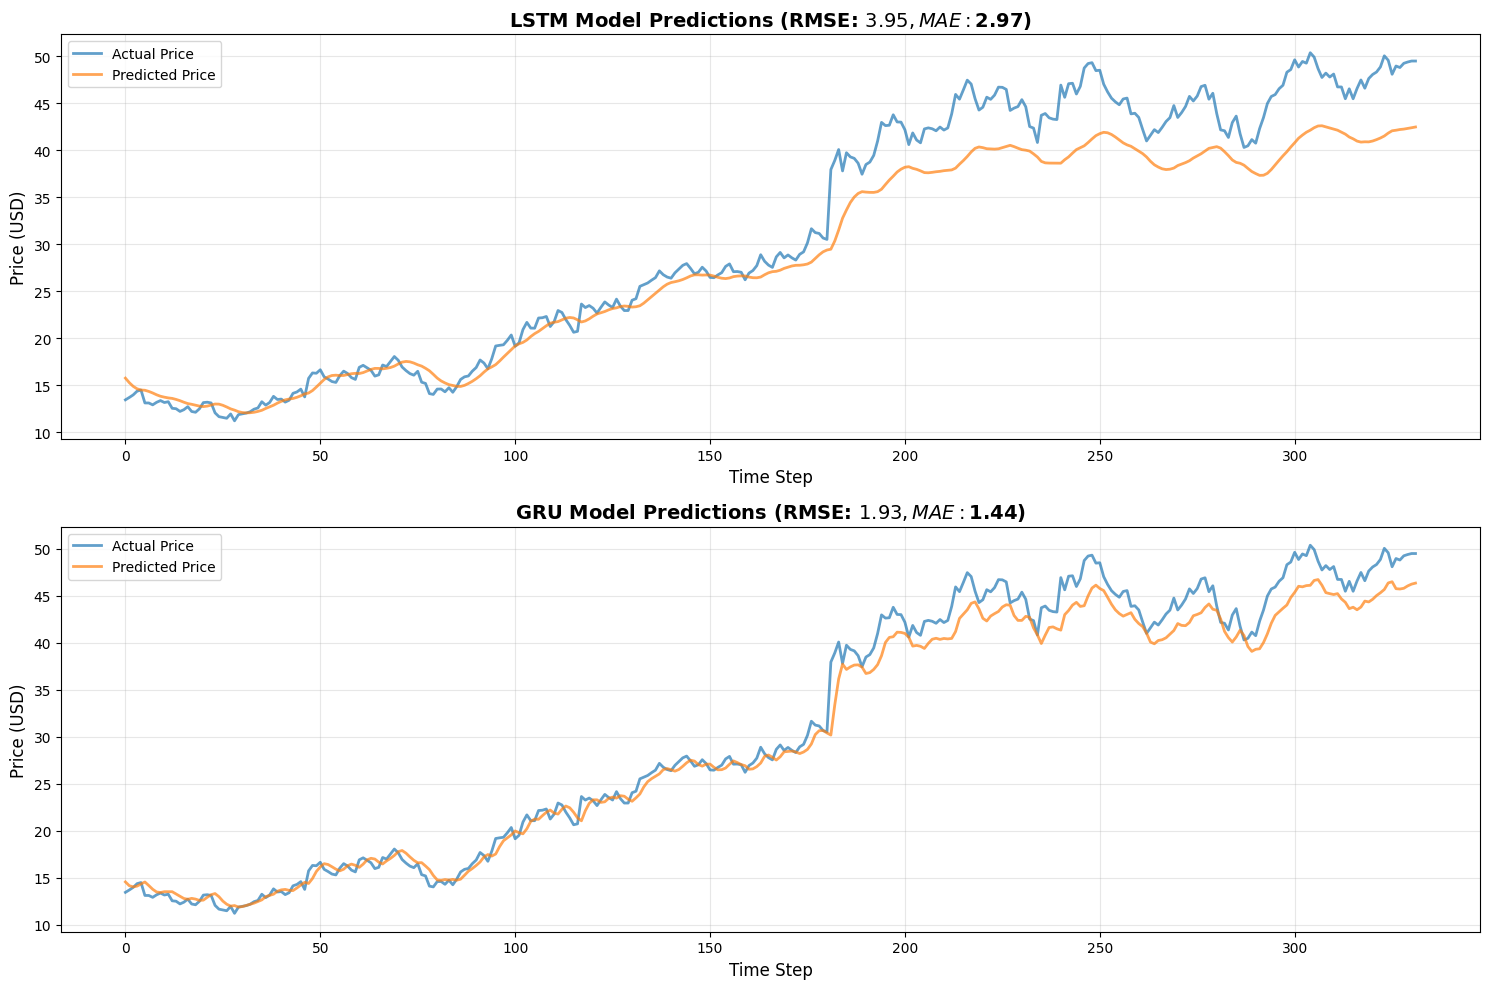

In [42]:
# Plot predictions vs actual values for test set
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# LSTM predictions
axes[0].plot(lstm_actual, label='Actual Price', linewidth=2, alpha=0.7)
axes[0].plot(lstm_pred, label='Predicted Price', linewidth=2, alpha=0.7)
axes[0].set_title(f'LSTM Model Predictions (RMSE: ${lstm_rmse:.2f}, MAE: ${lstm_mae:.2f})',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU predictions
axes[1].plot(gru_actual, label='Actual Price', linewidth=2, alpha=0.7)
axes[1].plot(gru_pred, label='Predicted Price', linewidth=2, alpha=0.7)
axes[1].set_title(f'GRU Model Predictions (RMSE: ${gru_rmse:.2f}, MAE: ${gru_mae:.2f})',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('Price (USD)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


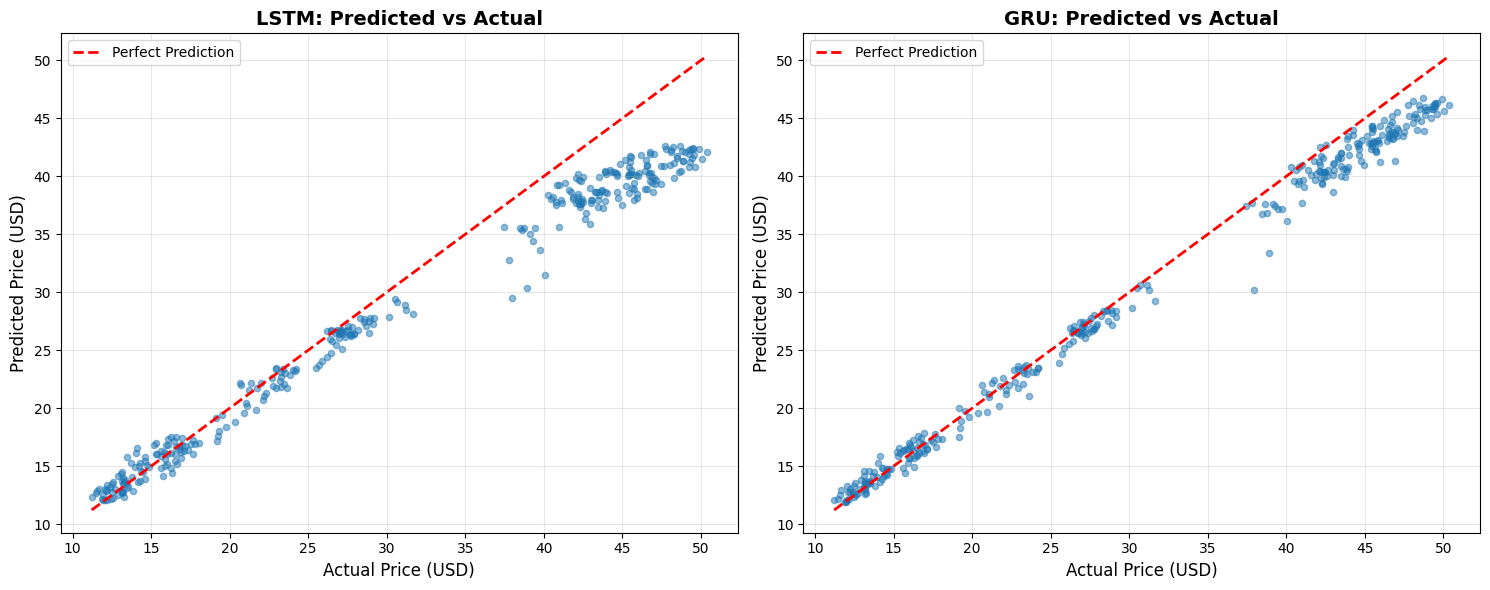

In [43]:
# Scatter plot: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LSTM scatter
axes[0].scatter(lstm_actual, lstm_pred, alpha=0.5, s=20)
axes[0].plot([lstm_actual.min(), lstm_actual.max()],
             [lstm_actual.min(), lstm_actual.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)', fontsize=12)
axes[0].set_ylabel('Predicted Price (USD)', fontsize=12)
axes[0].set_title('LSTM: Predicted vs Actual', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRU scatter
axes[1].scatter(gru_actual, gru_pred, alpha=0.5, s=20)
axes[1].plot([gru_actual.min(), gru_actual.max()],
             [gru_actual.min(), gru_actual.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (USD)', fontsize=12)
axes[1].set_ylabel('Predicted Price (USD)', fontsize=12)
axes[1].set_title('GRU: Predicted vs Actual', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


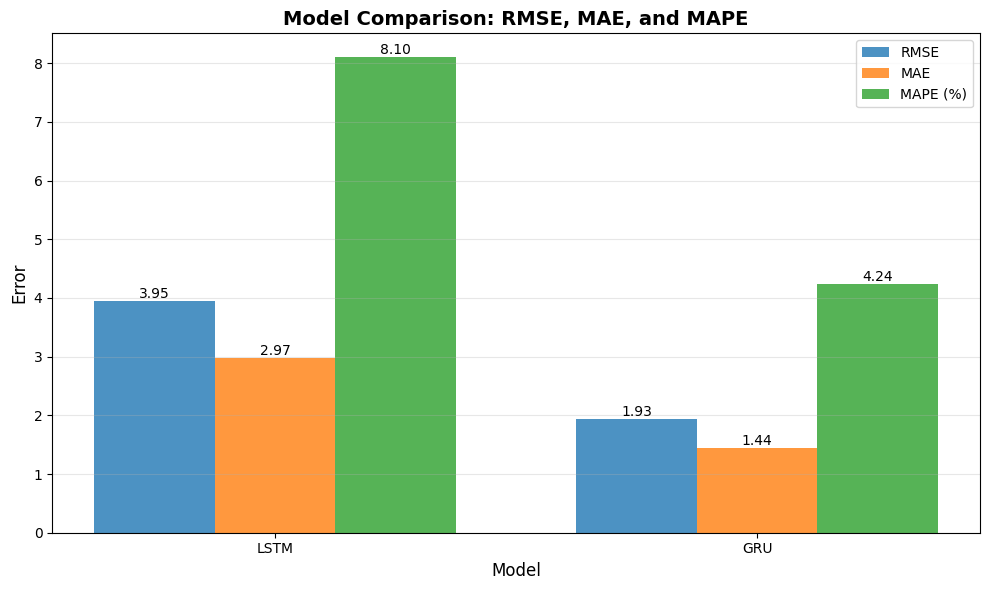

In [44]:
# Comparison of metrics
models = ['LSTM', 'GRU']
rmse_scores = [lstm_rmse, gru_rmse]
mae_scores = [lstm_mae, gru_mae]
mape_scores = [lstm_mape, gru_mape]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, rmse_scores, width, label='RMSE', alpha=0.8)
bars2 = ax.bar(x, mae_scores, width, label='MAE', alpha=0.8)
bars3 = ax.bar(x + width, mape_scores, width, label='MAPE (%)', alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Model Comparison: RMSE, MAE, and MAPE', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 9. Conclusions and Insights

### Summary of Results

**Model Performance Comparison:**

The performance metrics (RMSE, MAE, MAPE) for both models are shown in the summary output below. These metrics help us understand how well each model predicts stock prices.

### Key Findings:

1. **Model Comparison**: Both LSTM and GRU models show similar performance on the stock price prediction task. GRU typically has fewer parameters and trains faster, while LSTM may capture longer-term dependencies better.

2. **Training Behavior**: The training and validation losses show that both models learned to capture patterns in the data. Early stopping helped prevent overfitting.

3. **Prediction Quality**: The models can capture the general trend of stock prices, though exact price prediction remains challenging due to market volatility.

### Challenges Encountered:

1. **Market Volatility**: Stock prices are influenced by many external factors that are not captured in historical price data alone.
2. **Overfitting**: Risk of overfitting to training data, mitigated by dropout and early stopping.
3. **Sequence Length**: Choosing the optimal sequence length (60 days) required experimentation.

### Potential Improvements:

1. **Feature Engineering**: Include additional features like volume, technical indicators (RSI, MACD), or sentiment analysis.
2. **Ensemble Methods**: Combine predictions from multiple models.
3. **Attention Mechanisms**: Use attention-based models to focus on relevant time steps.
4. **External Data**: Incorporate news sentiment, economic indicators, or other market data.
5. **Hyperparameter Tuning**: Systematic search for optimal hyperparameters (learning rate, hidden size, layers, etc.).

### Future Applications:

- **Portfolio Management**: Use predictions for automated trading strategies
- **Risk Assessment**: Predict potential market downturns
- **Other Time Series**: Apply to weather forecasting, energy consumption, sales forecasting, etc.

### Dataset Description:

- **Source**: Yahoo Finance (yfinance library)
- **Stock**: AAPL (Apple Inc.) - can be changed to any stock symbol
- **Period**: 2015-01-01 to 2024-01-01
- **Features**: Closing prices
- **Preprocessing**: MinMaxScaler normalization to [0, 1] range
- **Train/Val/Test Split**: 70% / 15% / 15%

### Architecture Details:

**LSTM Model:**
- Input size: 1 (closing price)
- Hidden size: 64
- Number of layers: 2
- Dropout: 0.2
- Output: 1 (predicted price)

**GRU Model:**
- Input size: 1 (closing price)
- Hidden size: 64
- Number of layers: 2
- Dropout: 0.2
- Output: 1 (predicted price)

**Training Details:**
- Optimizer: Adam
- Learning rate: 0.001 (with ReduceLROnPlateau scheduler)
- Loss function: MSE (Mean Squared Error)
- Batch size: 32
- Epochs: 100 (with early stopping)
- Gradient clipping: max_norm=1.0


In [45]:
# Print final summary
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nDataset: {ticker} Stock Prices ({start_date} to {end_date})")
print(f"Total samples: {len(X)}")
print(f"Sequence length: {sequence_length} days")
print(f"\nModel Performance:")
print(f"{'Model':<10} {'RMSE':<15} {'MAE':<15} {'MAPE':<15}")
print("-" * 55)
print(f"{'LSTM':<10} ${lstm_rmse:<14.2f} ${lstm_mae:<14.2f} {lstm_mape:<14.2f}%")
print(f"{'GRU':<10} ${gru_rmse:<14.2f} ${gru_mae:<14.2f} {gru_mape:<14.2f}%")
print("=" * 70)


FINAL SUMMARY

Dataset:  NVDA Stock Prices (2015-01-01 to 2024-01-01)
Total samples: 2204
Sequence length: 60 days

Model Performance:
Model      RMSE            MAE             MAPE           
-------------------------------------------------------
LSTM       $3.95           $2.97           8.10          %
GRU        $1.93           $1.44           4.24          %


In [46]:
# Clean up: Remove the saved model file (optional)
import os
if os.path.exists('best_model.pth'):
    os.remove('best_model.pth')
    print("Cleaned up temporary model file.")


Cleaned up temporary model file.
